<a href="https://colab.research.google.com/github/kvlaskarolina/JU-sem6-IAI/blob/main/03_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Zadanie 1: Hesjan i Klasyfikacja Punktów Krytycznych (PyTorch)
Rozważmy nową funkcję, której nie było na wykładzie:
$$f(w_1, w_2) = w_1^3 + w_2^3 - 3w_1w_2$$

Z analizy matematycznej (przyrównania gradientu do zera) wynika, że funkcja ta posiada dokładnie dwa punkty krytyczne: $A=(0,0)$ oraz $B=(1,1)$.
Zgodnie z Twierdzeniem Sylvestera (z wykładu), charakter tych punktów zależy od wartości własnych macierzy drugich pochodnych (Hesjanu).

**Twoje zadanie:**
1. Zdefiniuj tę funkcję w PyTorchu.
2. Użyj funkcji `torch.autograd.functional.hessian`, aby wyliczyć macierze Hesjanu dla **obu** punktów: `[0.0, 0.0]` oraz `[1.0, 1.0]`.
3. Wykorzystaj `torch.linalg.eigvals()`, aby obliczyć wartości własne dla obu macierzy.
4. Wydrukuj wartości własne i napisz w komentarzu klasyfikację obu punktów (minimum, maksimum czy punkt siodłowy) uzasadniając to teorią z wykładu.

In [2]:
import torch

def f(w):
    w1, w2 = w[0], w[1]
    return w1**3 + w2**3 - 3*w1*w2

point_A = torch.tensor([0.0, 0.0], requires_grad=True)
point_B = torch.tensor([1.0, 1.0], requires_grad=True)

hessian_matrix_A = torch.autograd.functional.hessian(f,point_A)
hessian_matrix_B = torch.autograd.functional.hessian(f,point_B)

print("Hessian matrix for point A (0,0):")
print(hessian_matrix_A)
print("Hessian matrix for point B (1,1):")
print(hessian_matrix_B)

eigenvalues_A = torch.linalg.eigvals(hessian_matrix_A)
eigenvalues_B = torch.linalg.eigvals(hessian_matrix_B)

print("\n--- Analysis for Point A (0,0) ---")
print("Eigenvalues for A:")
print(eigenvalues_A)
if torch.all(eigenvalues_A.real > 0):
        print ("Klasyfikacja: Lokalne minimum (Dodatnio określony Hesjan).")
elif torch.all(eigenvalues_A.real < 0):
        print ("Klasyfikacja: Lokalne maksimum (Ujemnie określony Hesjan).")
elif torch.any(eigenvalues_A.real > 0) and torch.any(eigenvalues_A.real < 0):
        print ("Klasyfikacja: Punkt siodłowy (Nieokreślony Hesjan).")
elif torch.all(eigenvalues_A.real >= 0) and torch.any(eigenvalues_A.real == 0):
        print ("Klasyfikacja: Punkt krytyczny, test niekonkluzywny (Dodatnio półokreślony Hesjan).")
elif torch.all(eigenvalues_A.real <= 0) and torch.any(eigenvalues_A.real == 0):
        print ("Klasyfikacja: Punkt krytyczny, test niekonkluzywny (Ujemnie półokreślony Hesjan).")
else:
        print ("Klasyfikacja: Nieokreślona (Indefinite).")

print("\n--- Analysis for Point B (1,1) ---")
print("Eigenvalues for B:")
print(eigenvalues_B)
if torch.all(eigenvalues_B.real > 0):
        print ("Klasyfikacja: Lokalne minimum (Dodatnio określony Hesjan).")
elif torch.all(eigenvalues_B.real < 0):
        print ("Klasyfikacja: Lokalne maksimum (Ujemnie określony Hesjan).")
elif torch.any(eigenvalues_B.real > 0) and torch.any(eigenvalues_B.real < 0):
        print ("Klasyfikacja: Punkt siodłowy (Nieokreślony Hesjan).")
elif torch.all(eigenvalues_B.real >= 0) and torch.any(eigenvalues_B.real == 0):
        print ("Klasyfikacja: Punkt krytyczny, test niekonkluzywny (Dodatnio półokreślony Hesjan).")
elif torch.all(eigenvalues_B.real <= 0) and torch.any(eigenvalues_B.real == 0):
        print ("Klasyfikacja: Punkt krytyczny, test niekonkluzywny (Ujemnie półokreślony Hesjan).")
else:
        print ("Klasyfikacja: Nieokreślona (Indefinite).")


Hessian matrix for point A (0,0):
tensor([[ 0., -3.],
        [-3.,  0.]])
Hessian matrix for point B (1,1):
tensor([[ 6., -3.],
        [-3.,  6.]])

--- Analysis for Point A (0,0) ---
Eigenvalues for A:
tensor([ 3.+0.j, -3.+0.j])
Klasyfikacja: Punkt siodłowy (Nieokreślony Hesjan).

--- Analysis for Point B (1,1) ---
Eigenvalues for B:
tensor([9.+0.j, 3.+0.j])
Klasyfikacja: Lokalne minimum (Dodatnio określony Hesjan).


## Zadanie 2: Krzywa Overfittingu (Train / Test Split)
Najważniejszą koncepcją Machine Learningu nie jest zapamiętanie danych, ale generalizacja.

Wygenerowaliśmy dla Ciebie zbiór 40 punktów (krzywa sinus).
**Twoje zadanie:**
1. Podziel zbiór danych: pierwsze 20 punktów do treningu (`X_train`, `y_train`), a co drugie 20 punktów do testów (`X_test`, `y_test`). Pamiętaj o posortowaniu osi X! (Możesz też użyć wbudowanej funkcji `train_test_split` ze sklearn).
2. W pętli, dla każdego stopnia wielomianu od 1 do 15:
   - Wygeneruj cechy wielomianowe (możesz użyć `np.polyfit` / `np.polyval` dla ułatwienia, lub własnej funkcji).
   - Dopasuj model metodą najmniejszych kwadratów **tylko** na zbiorze treningowym.
   - Oblicz błąd MSE (Mean Squared Error) dla zbioru treningowego oraz dla zbioru testowego.
3. Narysuj wykres liniowy: Oś X to stopień wielomianu, Oś Y to błąd MSE. Na wykresie mają znaleźć się dwie linie: błąd treningowy i błąd testowy. Skalę osi Y ustaw na logarytmiczną (`plt.yscale('log')`).

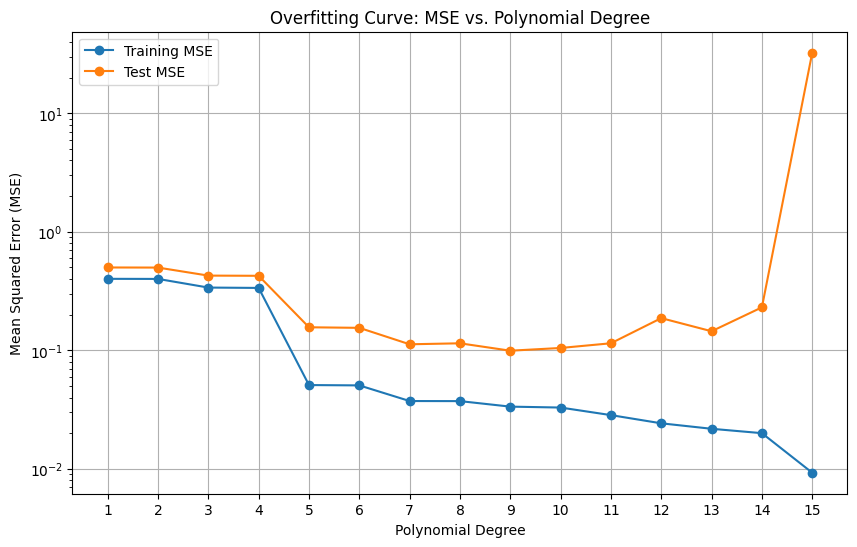

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

np.random.seed(42)
X = np.sort(np.random.uniform(0, 4*np.pi, 40))
y = np.sin(X) + np.random.normal(0, 0.3, 40)


# alt
# X_train = X[:20]
# X_test  = X[20:]
# Y_train = Y[:20]
# Y_test  = Y[20:]

X_train = X[::2]
y_train = y[::2]

X_test  = X[1::2]
y_test  = y[1::2]

mse_train_errors = []
mse_test_errors = []

for degree in range(1, 16):
    coeffs = np.polyfit(X_train, y_train, degree)

    y_train_pred = np.polyval(coeffs, X_train)
    y_test_pred = np.polyval(coeffs, X_test)

    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)

    mse_train_errors.append(mse_train)
    mse_test_errors.append(mse_test)

degrees = range(1, 16)
plt.figure(figsize=(10, 6))
plt.plot(degrees, mse_train_errors, label='Training MSE', marker='o')
plt.plot(degrees, mse_test_errors, label='Test MSE', marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Overfitting Curve: MSE vs. Polynomial Degree')
plt.yscale('log')
plt.xticks(degrees)
plt.legend()
plt.grid(True)
plt.show()

## Zadanie 3: Manualna K-krotna Cross-Walidacja
Czasami zbiór danych jest tak mały, że jednorazowy podział na Train/Test to za mało. Wykład mówił o Cross-Walidacji.

**Twoje zadanie:**
Masz wektor cech `X` i `y` (po 30 elementów). Napisz własną pętlę implementującą 3-krotną cross-walidację (3-Fold CV).
1. Podziel zbiory na 3 równe paczki (foldy) po 10 elementów.
2. Wykonaj 3 iteracje uczenia. W każdej iteracji weź jeden fold jako zbiór testowy, a połączone dwa pozostałe foldy jako zbiór treningowy.
3. Oblicz błąd testowy dla każdego z 3 modeli i na koniec wypisz ich **średnią**.
*(Wskazówka: Skorzystaj z cięcia list/tablic numpy (slicing) oraz funkcji `np.concatenate`).*

In [6]:
# Dane (30 punktów)
X_cv = np.linspace(0, 10, 30)
y_cv = 2 * X_cv + 1 + np.random.normal(0, 1, 30)

# TODO: Podziel zbiór na 3 foldy i wykonaj pętlę cross-walidacji
# Jako model użyj po prostu np.polyfit(..., 1) i np.polyval

k = 3
fold_size = len(X_cv) // k

test_errors = []

for i in range(k):
    test_start = i * fold_size
    test_end   = test_start + fold_size

    X_test  = X_cv[test_start:test_end]
    y_test  = y_cv[test_start:test_end]

    X_train = np.concatenate([X_cv[:test_start], X_cv[test_end:]])
    y_train = np.concatenate([y_cv[:test_start], y_cv[test_end:]])

    coeffs      = np.polyfit(X_train, y_train, 1)
    y_test_pred = np.polyval(coeffs, X_test)

    mse = mean_squared_error(y_test, y_test_pred)
    test_errors.append(mse)
    print(f"Fold {i+1}: test_start={test_start}, test_end={test_end}, MSE={mse:.4f}")

print(f"\nŚredni błąd CV: {np.mean(test_errors):.4f}")


Fold 1: test_start=0, test_end=10, MSE=1.1706
Fold 2: test_start=10, test_end=20, MSE=0.7121
Fold 3: test_start=20, test_end=30, MSE=0.8175

Średni błąd CV: 0.9001


## Zadanie 4: Selekcja Cech (Ridge vs Lasso)
Zgodnie ze slajdami z wykładu, Brzytwa Ockhama karze modele zbyt skomplikowane. Lasso (norma L1) potrafi całkowicie wyzerować niepotrzebne cechy, robiąc automatyczną selekcję. Ridge (norma L2) tylko je zmniejsza.

**Twoje zadanie:**
Wygenerowaliśmy zestaw danych, w którym jest 1 sensowna cecha i aż 50 kolumn czystego szumu (bezużyteczne cechy).
1. Wytrenuj model `Ridge` z biblioteki `sklearn.linear_model` (z parametrem `alpha=1.0`).
2. Wytrenuj model `Lasso` z biblioteki `sklearn.linear_model` (z parametrem `alpha=0.1`).
3. Sprawdź atrybut `.coef_` w obu modelach. Policz, ile dokładnie współczynników (wag) model Lasso zredukował **idealnie do zera**, a ile model Ridge. Wypisz te współczynniki.

In [7]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.datasets import make_regression

X_reg, y_reg = make_regression(n_samples=100, n_features=51, n_informative=1, noise=10, random_state=42)

ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)

ridge.fit(X_reg, y_reg)
lasso.fit(X_reg, y_reg)

ridge_zeros = np.sum(ridge.coef_ == 0.0)
lasso_zeros = np.sum(lasso.coef_ == 0.0)

print(f"Ridge — współczynniki równe 0: {ridge_zeros} / {len(ridge.coef_)}")
print(f"Lasso — współczynniki równe 0: {lasso_zeros} / {len(lasso.coef_)}")

print(f"\nRidge .coef_:\n{np.round(ridge.coef_, 3)}")
print(f"\nLasso .coef_:\n{np.round(lasso.coef_, 3)}")

Ridge — współczynniki równe 0: 0 / 51
Lasso — współczynniki równe 0: 9 / 51

Ridge .coef_:
[ 1.3830e+00 -3.8100e-01 -7.3000e-02 -5.8300e-01 -4.2080e+00  8.7000e-01
  4.9700e-01 -1.9840e+00  5.5000e-01  1.9000e-02  5.3000e-02  2.6570e+00
  5.8700e-01  3.0580e+00  1.4140e+00 -4.5700e-01  1.9150e+00 -5.3700e-01
  2.8720e+00  2.8800e-01 -1.1580e+00  1.5730e+00  2.7050e+00 -1.2730e+00
  1.7100e-01  8.5800e-01 -1.3100e+00 -2.1700e+00  5.5200e-01  6.6800e-01
  2.1540e+00  7.6000e-02 -3.8600e-01 -1.3100e+00 -1.6110e+00  2.8570e+00
  1.5270e+00 -1.3840e+00 -1.3750e+00 -6.6700e-01 -1.2440e+00  6.3000e-01
 -7.6800e-01  7.9100e-01  5.2400e-01  2.7500e-01 -9.0100e-01  8.6000e-02
 -2.0790e+00 -1.5960e+00  9.1294e+01]

Lasso .coef_:
[ 9.1700e-01 -4.8800e-01  1.8000e-02 -0.0000e+00 -3.9360e+00  5.1800e-01
  0.0000e+00 -1.3290e+00  5.5700e-01  0.0000e+00  3.0000e-03  2.5160e+00
  5.9100e-01  2.2930e+00  8.0200e-01 -8.1800e-01  1.3010e+00 -5.3200e-01
  2.5150e+00  0.0000e+00 -9.9400e-01  1.3950e+00  1.8